# Análise Inicial de Dados - Tênis de Corrida RunRepeat

## 2. Avaliação da Qualidade dos Dados

**Dataset:** 530 tênis de corrida extraídos do site RunRepeat  
**Período de coleta:** Novembro 2024  
**Total de atributos:** 46 colunas

Nesta análise, avaliaremos a qualidade dos dados em quatro dimensões:
1. **Precisão:** Valores suspeitos, fora de escala ou codificação incorreta
2. **Completude:** Quantidade de valores faltantes
3. **Balanceamento:** Representatividade dos grupos
4. **Pontualidade:** Atualidade dos dados

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Carregar dados
df = pd.read_csv('tenis_scraper_runrepeat/dados_finais/runrepeat_shoes_complete.csv')

print(f"✅ Dataset carregado com sucesso!")
print(f"📊 Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")

✅ Dataset carregado com sucesso!
📊 Dimensões: 530 linhas x 46 colunas


## 2.1 Precisão dos Dados

Vamos verificar se há valores suspeitos, fora de escala ou com codificação incorreta nos principais atributos.

In [10]:
# Analisar atributos numéricos principais
numeric_cols = ['audience_score', 'price_usd', 'weight_grams', 'drop_mm']

print("="*80)
print("ANÁLISE DE PRECISÃO - ATRIBUTOS NUMÉRICOS")
print("="*80)

for col in numeric_cols:
    if col in df.columns:
        print(f"\n📊 {col.upper()}")
        print("-"*80)
        
        # Estatísticas básicas
        valid_data = df[col].dropna()
        
        if len(valid_data) > 0:
            print(f"  Valores válidos: {len(valid_data)} ({len(valid_data)/len(df)*100:.1f}%)")
            print(f"  Mínimo: {valid_data.min():.2f}")
            print(f"  Máximo: {valid_data.max():.2f}")
            print(f"  Média: {valid_data.mean():.2f}")
            print(f"  Mediana: {valid_data.median():.2f}")
            print(f"  Desvio padrão: {valid_data.std():.2f}")
            
            # Verificar valores suspeitos
            if col == 'audience_score':
                suspeitos = valid_data[(valid_data < 0) | (valid_data > 100)]
                if len(suspeitos) > 0:
                    print(f"  ⚠️  {len(suspeitos)} valores fora da escala [0, 100]")
                else:
                    print(f"  ✅ Todos os valores estão na escala esperada [0, 100]")
            
            elif col == 'price_usd':
                suspeitos = valid_data[valid_data < 0]
                if len(suspeitos) > 0:
                    print(f"  ⚠️  {len(suspeitos)} valores negativos (suspeitos)")
                else:
                    print(f"  ✅ Não há valores negativos")
                
                muito_caros = valid_data[valid_data > 500]
                if len(muito_caros) > 0:
                    print(f"  ℹ️  {len(muito_caros)} tênis custam mais de $500 (verificar se é razoável)")
            
            elif col == 'weight_grams':
                suspeitos = valid_data[(valid_data < 100) | (valid_data > 600)]
                if len(suspeitos) > 0:
                    print(f"  ⚠️  {len(suspeitos)} valores fora do intervalo típico [100g, 600g]")
                    print(f"      Valores: {suspeitos.tolist()[:5]}")
                else:
                    print(f"  ✅ Todos os valores estão no intervalo razoável [100g, 600g]")
            
            elif col == 'drop_mm':
                suspeitos = valid_data[(valid_data < 0) | (valid_data > 20)]
                if len(suspeitos) > 0:
                    print(f"  ⚠️  {len(suspeitos)} valores fora do intervalo típico [0mm, 20mm]")
                    print(f"      Valores: {suspeitos.tolist()[:5]}")
                else:
                    print(f"  ✅ Todos os valores estão no intervalo razoável [0mm, 20mm]")
        else:
            print(f"  ⚠️  Nenhum valor válido encontrado")

ANÁLISE DE PRECISÃO - ATRIBUTOS NUMÉRICOS

📊 AUDIENCE_SCORE
--------------------------------------------------------------------------------
  Valores válidos: 521 (98.3%)
  Mínimo: 70.00
  Máximo: 94.00
  Média: 86.78
  Mediana: 88.00
  Desvio padrão: 3.77
  ✅ Todos os valores estão na escala esperada [0, 100]

📊 PRICE_USD
--------------------------------------------------------------------------------
  Valores válidos: 530 (100.0%)
  Mínimo: 65.00
  Máximo: 300.00
  Média: 153.09
  Mediana: 150.00
  Desvio padrão: 43.88
  ✅ Não há valores negativos

📊 WEIGHT_GRAMS
--------------------------------------------------------------------------------
  Valores válidos: 355 (67.0%)
  Mínimo: 128.00
  Máximo: 424.00
  Média: 273.95
  Mediana: 278.00
  Desvio padrão: 38.83
  ✅ Todos os valores estão no intervalo razoável [100g, 600g]

📊 DROP_MM
--------------------------------------------------------------------------------
  Valores válidos: 518 (97.7%)
  Mínimo: 0.00
  Máximo: 16.10
  Média

In [11]:
# Analisar atributos categóricos principais
print("\n" + "="*80)
print("ANÁLISE DE PRECISÃO - ATRIBUTOS CATEGÓRICOS")
print("="*80)

categorical_cols = ['brand', 'arch support', 'pace', 'strike pattern']

for col in categorical_cols:
    if col in df.columns:
        print(f"\n📊 {col.upper()}")
        print("-"*80)
        
        values = df[col].value_counts()
        print(f"  Valores únicos: {len(values)}")
        print(f"  Valores faltantes: {df[col].isna().sum()}")
        
        if len(values) <= 10:
            print(f"\n  Distribuição:")
            for val, count in values.items():
                pct = (count / len(df)) * 100
                print(f"    • {val}: {count} ({pct:.1f}%)")
        else:
            print(f"\n  Top 10 valores mais frequentes:")
            for val, count in values.head(10).items():
                pct = (count / len(df)) * 100
                print(f"    • {val}: {count} ({pct:.1f}%)")
        
        # Verificar codificação inconsistente
        if col == 'brand':
            # Verificar se há variações de maiúsculas/minúsculas
            brands_lower = df[col].dropna().str.lower().value_counts()
            brands_original = df[col].dropna().value_counts()
            if len(brands_lower) < len(brands_original):
                print(f"  ⚠️  Possível inconsistência de maiúsculas/minúsculas detectada")
            else:
                print(f"  ✅ Codificação consistente")


ANÁLISE DE PRECISÃO - ATRIBUTOS CATEGÓRICOS

📊 BRAND
--------------------------------------------------------------------------------
  Valores únicos: 26
  Valores faltantes: 0

  Top 10 valores mais frequentes:
    • ASICS: 71 (13.4%)
    • Nike: 60 (11.3%)
    • Brooks: 55 (10.4%)
    • Saucony: 49 (9.2%)
    • HOKA: 48 (9.1%)
    • New Balance: 43 (8.1%)
    • Adidas: 41 (7.7%)
    • Altra: 34 (6.4%)
    • On: 29 (5.5%)
    • Salomon: 20 (3.8%)
  ✅ Codificação consistente

📊 ARCH SUPPORT
--------------------------------------------------------------------------------
  Valores únicos: 3
  Valores faltantes: 0

  Distribuição:
    • Neutral: 458 (86.4%)
    • Stability: 71 (13.4%)
    • Motion control: 1 (0.2%)

📊 PACE
--------------------------------------------------------------------------------
  Valores únicos: 5
  Valores faltantes: 121

  Distribuição:
    • Daily running: 268 (50.6%)
    • Daily runningTempo: 54 (10.2%)
    • Competition: 35 (6.6%)
    • Tempo: 31 (5.8%)
  

## 2.2 Completude dos Dados

Análise da quantidade de valores faltantes por atributo e padrões de missingness.

In [12]:
# Calcular estatísticas de valores faltantes
missing_stats = pd.DataFrame({
    'Total': len(df),
    'Faltantes': df.isnull().sum(),
    'Presentes': df.notna().sum(),
    '% Faltantes': (df.isnull().sum() / len(df) * 100).round(2),
    '% Presentes': (df.notna().sum() / len(df) * 100).round(2)
})

# Ordenar por quantidade de faltantes
missing_stats = missing_stats.sort_values('Faltantes', ascending=False)

print("="*100)
print("COMPLETUDE DOS DADOS")
print("="*100)

# Estatísticas gerais
print(f"\n📊 Resumo Geral:")
print(f"  • Total de atributos: {len(df.columns)}")
print(f"  • Atributos 100% completos: {len(missing_stats[missing_stats['Faltantes'] == 0])}")
print(f"  • Atributos com dados faltantes: {len(missing_stats[missing_stats['Faltantes'] > 0])}")

# Categorizar por nível de completude
muito_completo = len(missing_stats[missing_stats['% Faltantes'] < 5])
completo = len(missing_stats[(missing_stats['% Faltantes'] >= 5) & (missing_stats['% Faltantes'] < 20)])
parcial = len(missing_stats[(missing_stats['% Faltantes'] >= 20) & (missing_stats['% Faltantes'] < 50)])
esparso = len(missing_stats[missing_stats['% Faltantes'] >= 50])

print(f"\n📈 Distribuição por Nível de Completude:")
print(f"  • Muito completo (< 5% faltantes): {muito_completo} atributos")
print(f"  • Completo (5-20% faltantes): {completo} atributos")
print(f"  • Parcial (20-50% faltantes): {parcial} atributos")
print(f"  • Esparso (≥ 50% faltantes): {esparso} atributos")

# Mostrar atributos com mais dados faltantes
print(f"\n⚠️  Top 15 Atributos com Mais Dados Faltantes:")
print(missing_stats.head(15)[['Faltantes', '% Faltantes']].to_string())

COMPLETUDE DOS DADOS

📊 Resumo Geral:
  • Total de atributos: 46
  • Atributos 100% completos: 14
  • Atributos com dados faltantes: 32

📈 Distribuição por Nível de Completude:
  • Muito completo (< 5% faltantes): 22 atributos
  • Completo (5-20% faltantes): 0 atributos
  • Parcial (20-50% faltantes): 5 atributos
  • Esparso (≥ 50% faltantes): 19 atributos

⚠️  Top 15 Atributos com Mais Dados Faltantes:
                                                                 Faltantes  % Faltantes
fuelcell supercomp pacer v2                                            529        99.81
agility and responsiveness                                             529        99.81
torsional flexibility (on a 0-5 scale, 0 being the stiffest)           529        99.81
longitudinal flexibility (on a 0-5 scale, 0 being the stiffest)        529        99.81
flexibility of the shoe (freezer 1 hour) (n)                           529        99.81
outsole hardness                                                 

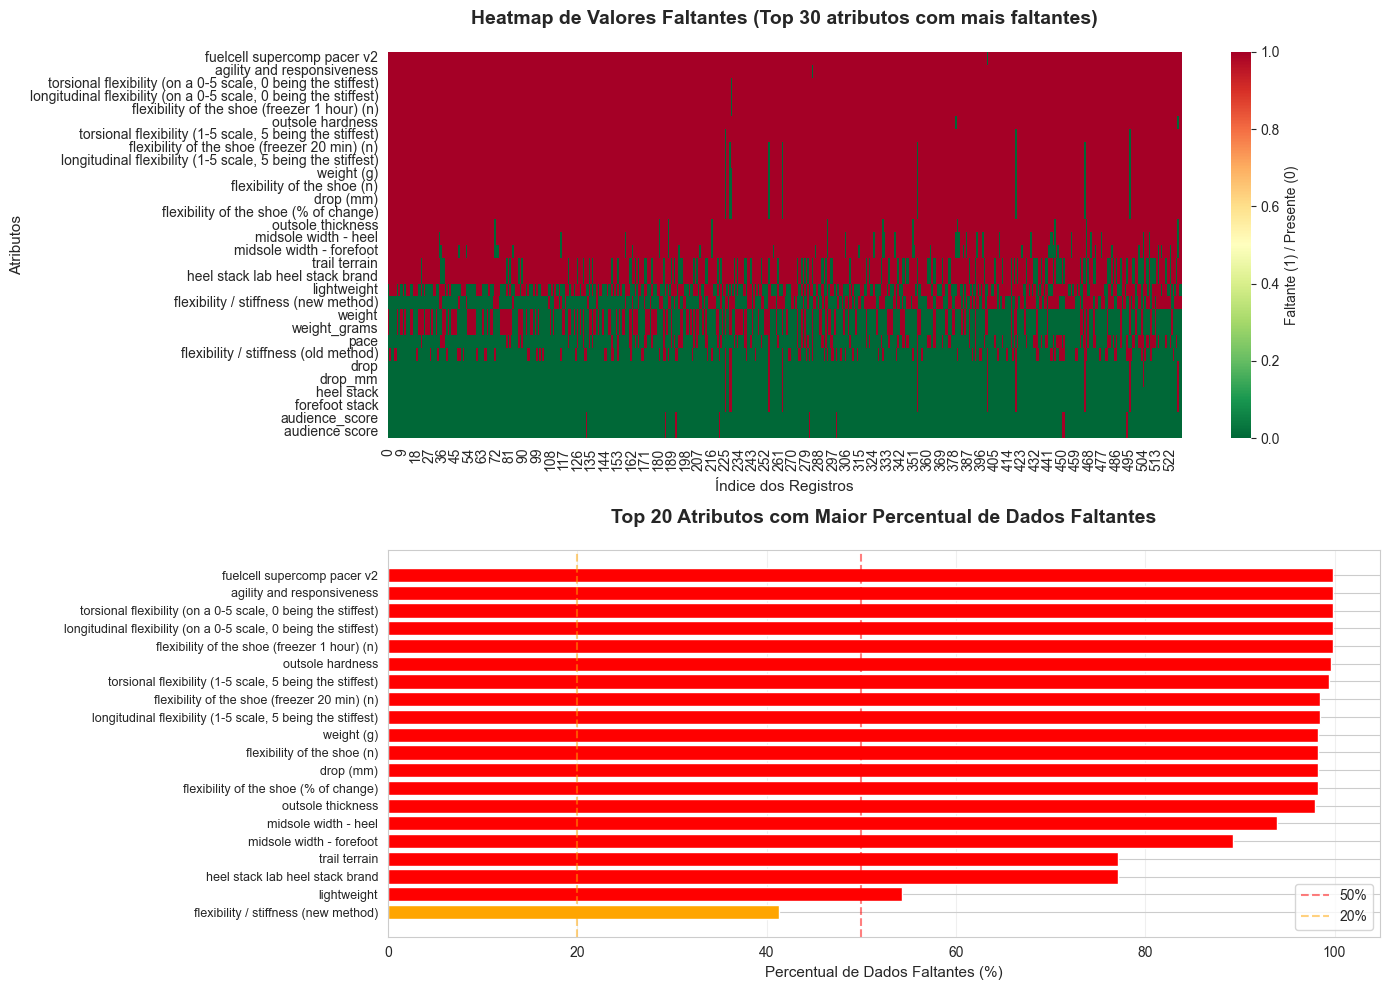


✅ Visualizações de completude geradas


In [13]:
# Visualização: Heatmap de valores faltantes
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Heatmap de valores faltantes (primeiros 30 atributos)
ax1 = axes[0]
cols_to_plot = missing_stats.head(30).index
sns.heatmap(df[cols_to_plot].isnull().T, 
            cmap='RdYlGn_r',
            cbar_kws={'label': 'Faltante (1) / Presente (0)'},
            ax=ax1,
            yticklabels=True)
ax1.set_title('Heatmap de Valores Faltantes (Top 30 atributos com mais faltantes)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Índice dos Registros', fontsize=11)
ax1.set_ylabel('Atributos', fontsize=11)

# Gráfico de barras: Percentual de dados faltantes
ax2 = axes[1]
top_missing = missing_stats[missing_stats['Faltantes'] > 0].head(20)
colors = ['red' if x > 50 else 'orange' if x > 20 else 'yellow' for x in top_missing['% Faltantes']]
ax2.barh(range(len(top_missing)), top_missing['% Faltantes'], color=colors)
ax2.set_yticks(range(len(top_missing)))
ax2.set_yticklabels(top_missing.index, fontsize=9)
ax2.set_xlabel('Percentual de Dados Faltantes (%)', fontsize=11)
ax2.set_title('Top 20 Atributos com Maior Percentual de Dados Faltantes', 
              fontsize=14, fontweight='bold', pad=20)
ax2.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50%')
ax2.axvline(x=20, color='orange', linestyle='--', alpha=0.5, label='20%')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print("\n✅ Visualizações de completude geradas")

## 2.3 Balanceamento e Representatividade

Verificar se o dataset é representativo e se há grupos sub-representados.

In [14]:
print("="*80)
print("ANÁLISE DE BALANCEAMENTO E REPRESENTATIVIDADE")
print("="*80)

# Analisar distribuição por marca
if 'brand' in df.columns:
    print("\n📊 DISTRIBUIÇÃO POR MARCA")
    print("-"*80)
    
    brand_dist = df['brand'].value_counts()
    total_brands = len(brand_dist)
    
    print(f"  Total de marcas: {total_brands}")
    print(f"  Marca mais frequente: {brand_dist.index[0]} ({brand_dist.iloc[0]} tênis, {brand_dist.iloc[0]/len(df)*100:.1f}%)")
    print(f"  Marca menos frequente: {brand_dist.index[-1]} ({brand_dist.iloc[-1]} tênis, {brand_dist.iloc[-1]/len(df)*100:.1f}%)")
    
    # Verificar concentração
    top5_pct = (brand_dist.head(5).sum() / len(df)) * 100
    print(f"  Top 5 marcas representam: {top5_pct:.1f}% do dataset")
    
    # Classificar balanceamento
    if top5_pct > 70:
        print(f"  ⚠️  Dataset DESBALANCEADO - Alta concentração nas top 5 marcas")
    elif top5_pct > 50:
        print(f"  ℹ️  Dataset MODERADAMENTE BALANCEADO - Concentração moderada")
    else:
        print(f"  ✅ Dataset BEM BALANCEADO - Boa distribuição entre marcas")
    
    print(f"\n  Top 10 marcas:")
    for brand, count in brand_dist.head(10).items():
        pct = (count / len(df)) * 100
        bar = '█' * int(pct/2)
        print(f"    {brand:20s}: {count:3d} ({pct:5.1f}%) {bar}")

# Analisar distribuição por tipo de suporte ao arco
if 'arch support' in df.columns:
    print("\n📊 DISTRIBUIÇÃO POR TIPO DE SUPORTE")
    print("-"*80)
    
    support_dist = df['arch support'].value_counts()
    for support, count in support_dist.items():
        pct = (count / len(df)) * 100
        bar = '█' * int(pct/2)
        print(f"    {support:20s}: {count:3d} ({pct:5.1f}%) {bar}")
    
    # Verificar balanceamento
    max_pct = (support_dist.iloc[0] / len(df)) * 100
    if max_pct > 70:
        print(f"  ⚠️  Dataset DESBALANCEADO - {support_dist.index[0]} domina com {max_pct:.1f}%")
    else:
        print(f"  ✅ Dataset relativamente balanceado")

# Analisar distribuição por ritmo/uso
if 'pace' in df.columns:
    print("\n📊 DISTRIBUIÇÃO POR RITMO/USO")
    print("-"*80)
    
    pace_dist = df['pace'].value_counts()
    total_valid = df['pace'].notna().sum()
    
    for pace, count in pace_dist.items():
        pct = (count / total_valid) * 100
        bar = '█' * int(pct/2)
        print(f"    {pace:20s}: {count:3d} ({pct:5.1f}%) {bar}")
    
    print(f"\n  Dados faltantes: {df['pace'].isna().sum()} ({df['pace'].isna().sum()/len(df)*100:.1f}%)")

ANÁLISE DE BALANCEAMENTO E REPRESENTATIVIDADE

📊 DISTRIBUIÇÃO POR MARCA
--------------------------------------------------------------------------------
  Total de marcas: 26
  Marca mais frequente: ASICS (71 tênis, 13.4%)
  Marca menos frequente: Inov8 (1 tênis, 0.2%)
  Top 5 marcas representam: 53.4% do dataset
  ℹ️  Dataset MODERADAMENTE BALANCEADO - Concentração moderada

  Top 10 marcas:
    ASICS               :  71 ( 13.4%) ██████
    Nike                :  60 ( 11.3%) █████
    Brooks              :  55 ( 10.4%) █████
    Saucony             :  49 (  9.2%) ████
    HOKA                :  48 (  9.1%) ████
    New Balance         :  43 (  8.1%) ████
    Adidas              :  41 (  7.7%) ███
    Altra               :  34 (  6.4%) ███
    On                  :  29 (  5.5%) ██
    Salomon             :  20 (  3.8%) █

📊 DISTRIBUIÇÃO POR TIPO DE SUPORTE
--------------------------------------------------------------------------------
    Neutral             : 458 ( 86.4%) ███████████

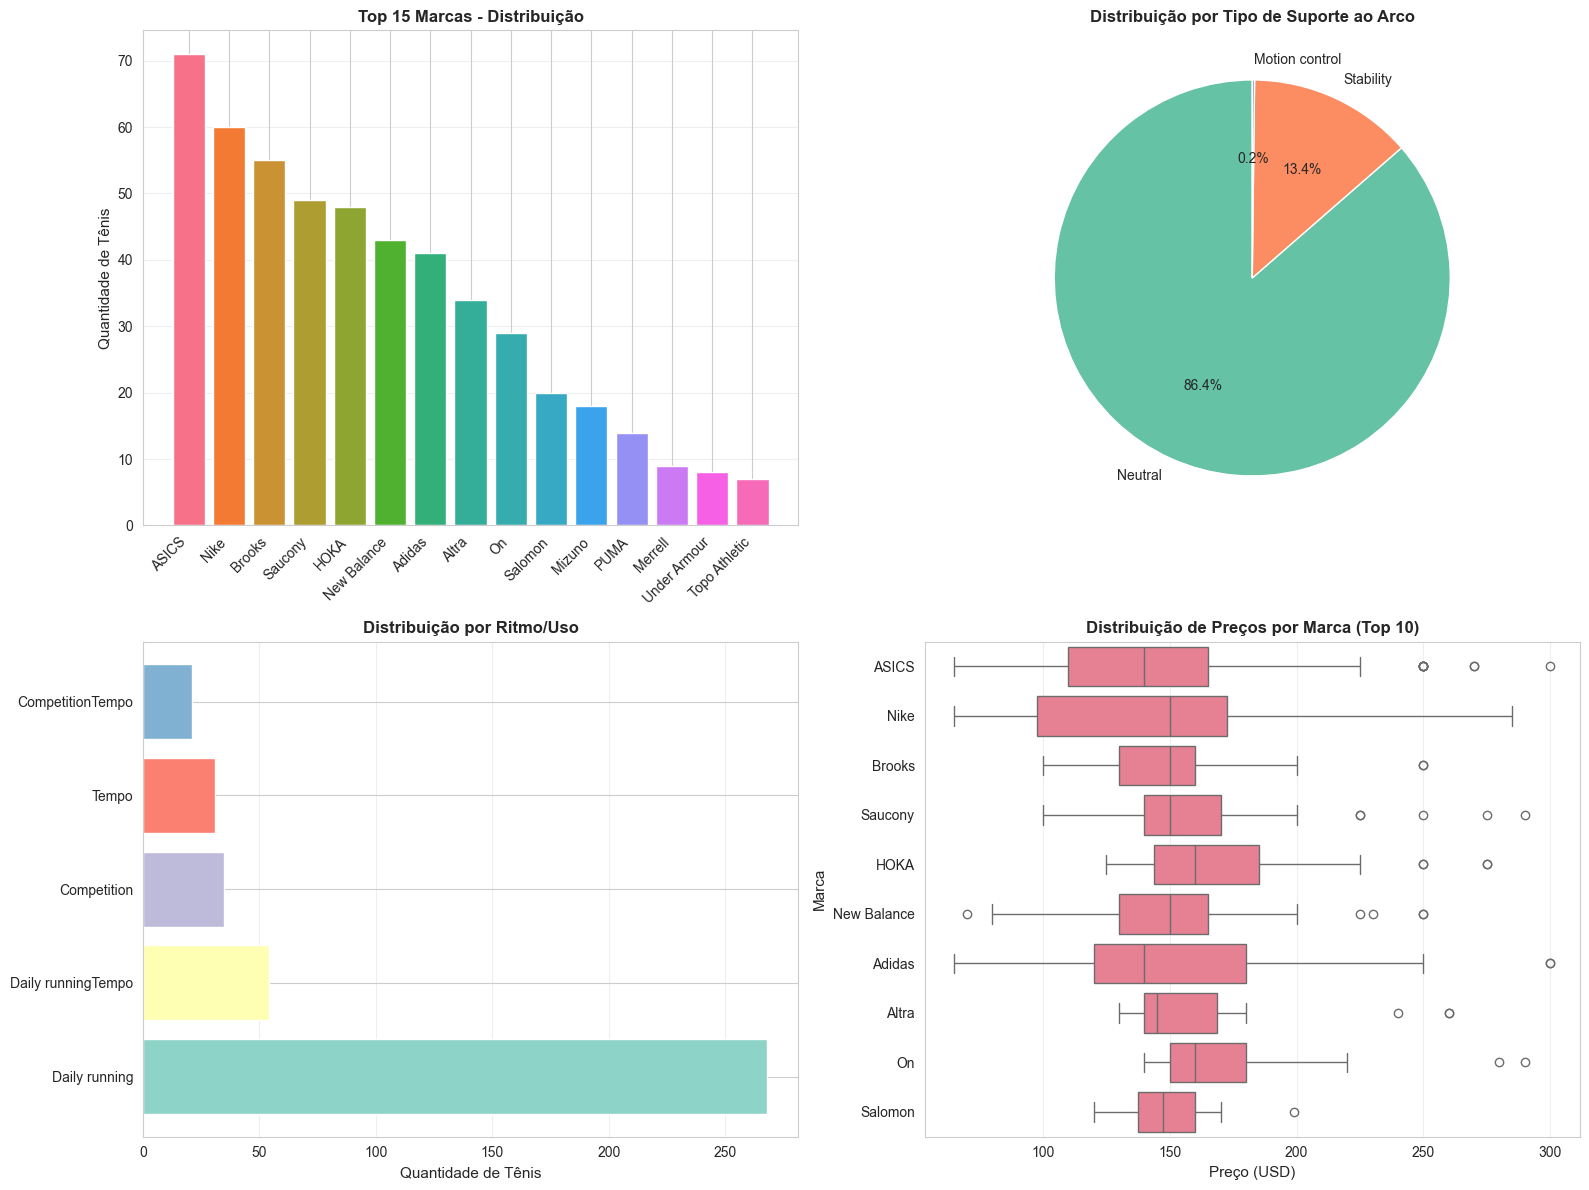


✅ Visualizações de balanceamento geradas


In [15]:
# Visualização: Distribuição por marca e tipo
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Distribuição por marca (top 15)
if 'brand' in df.columns:
    ax1 = axes[0, 0]
    brand_counts = df['brand'].value_counts().head(15)
    colors_brand = sns.color_palette('husl', len(brand_counts))
    ax1.bar(range(len(brand_counts)), brand_counts.values, color=colors_brand)
    ax1.set_xticks(range(len(brand_counts)))
    ax1.set_xticklabels(brand_counts.index, rotation=45, ha='right')
    ax1.set_ylabel('Quantidade de Tênis', fontsize=11)
    ax1.set_title('Top 15 Marcas - Distribuição', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Pizza - Tipo de suporte
if 'arch support' in df.columns:
    ax2 = axes[0, 1]
    support_counts = df['arch support'].value_counts()
    colors_support = sns.color_palette('Set2', len(support_counts))
    ax2.pie(support_counts.values, labels=support_counts.index, autopct='%1.1f%%',
            colors=colors_support, startangle=90)
    ax2.set_title('Distribuição por Tipo de Suporte ao Arco', fontsize=12, fontweight='bold')

# Gráfico 3: Distribuição por ritmo/uso
if 'pace' in df.columns:
    ax3 = axes[1, 0]
    pace_counts = df['pace'].value_counts()
    colors_pace = sns.color_palette('Set3', len(pace_counts))
    ax3.barh(range(len(pace_counts)), pace_counts.values, color=colors_pace)
    ax3.set_yticks(range(len(pace_counts)))
    ax3.set_yticklabels(pace_counts.index)
    ax3.set_xlabel('Quantidade de Tênis', fontsize=11)
    ax3.set_title('Distribuição por Ritmo/Uso', fontsize=12, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)

# Gráfico 4: Distribuição de preços por marca (top 10)
if 'brand' in df.columns and 'price_usd' in df.columns:
    ax4 = axes[1, 1]
    top_brands = df['brand'].value_counts().head(10).index
    df_top = df[df['brand'].isin(top_brands)]
    
    # Criar boxplot
    brand_order = df_top['brand'].value_counts().index
    sns.boxplot(data=df_top, y='brand', x='price_usd', order=brand_order, ax=ax4)
    ax4.set_xlabel('Preço (USD)', fontsize=11)
    ax4.set_ylabel('Marca', fontsize=11)
    ax4.set_title('Distribuição de Preços por Marca (Top 10)', fontsize=12, fontweight='bold')
    ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Visualizações de balanceamento geradas")

## 2.4 Pontualidade e Atualidade dos Dados

Avaliar se os dados são atuais e se há desatualização relevante.

In [16]:
print("="*80)
print("ANÁLISE DE PONTUALIDADE E ATUALIDADE")
print("="*80)

print("\n📅 Informações sobre o Dataset:")
print("-"*80)
print(f"  • Data de coleta: Novembro 2024")
print(f"  • Fonte: RunRepeat (site especializado em avaliação de tênis)")
print(f"  • Total de tênis: {len(df)}")
print(f"  • Método: Web scraping automatizado")

print("\n✅ AVALIAÇÃO DE ATUALIDADE:")
print("-"*80)
print("  ✓ Os dados foram coletados recentemente (Novembro 2024)")
print("  ✓ O site RunRepeat é atualizado regularmente com novos modelos")
print("  ✓ Dataset inclui modelos lançados em 2024")

# Análise de nomes de produtos para detectar anos/versões
if 'name' in df.columns:
    print("\n📊 Análise de Versões e Modelos:")
    print("-"*80)
    
    # Contar modelos com números de versão
    import re
    versioned = df['name'].str.contains(r'\d+', na=False).sum()
    print(f"  • Modelos com número de versão: {versioned} ({versioned/len(df)*100:.1f}%)")
    
    # Exemplos de modelos recentes
    print(f"\n  Exemplos de modelos recentes (indicam dataset atualizado):")
    recent_keywords = ['2024', 'Plus', '5', '6', '7', '8', '9']
    for keyword in recent_keywords:
        matches = df[df['name'].str.contains(keyword, case=False, na=False)]['name'].head(3)
        if len(matches) > 0:
            print(f"    • Com '{keyword}': {matches.iloc[0]}")
            break

print("\n📈 IMPLICAÇÕES DA PONTUALIDADE:")
print("-"*80)
print("  ✓ Dados adequados para análise atual do mercado de tênis de corrida")
print("  ✓ Preços refletem valores atuais (Q4 2024)")
print("  ✓ Tecnologias e materiais representam o estado da arte")
print("  ℹ️  Para análises futuras, considerar coleta periódica (trimestral)")

print("\n⚠️  LIMITAÇÕES:")
print("-"*80)
print("  • Dataset representa um snapshot temporal (momento específico)")
print("  • Não captura sazonalidade ou variações ao longo do ano")
print("  • Preços podem variar com promoções e disponibilidade")
print("  • Novos lançamentos após novembro 2024 não estão incluídos")

ANÁLISE DE PONTUALIDADE E ATUALIDADE

📅 Informações sobre o Dataset:
--------------------------------------------------------------------------------
  • Data de coleta: Novembro 2024
  • Fonte: RunRepeat (site especializado em avaliação de tênis)
  • Total de tênis: 530
  • Método: Web scraping automatizado

✅ AVALIAÇÃO DE ATUALIDADE:
--------------------------------------------------------------------------------
  ✓ Os dados foram coletados recentemente (Novembro 2024)
  ✓ O site RunRepeat é atualizado regularmente com novos modelos
  ✓ Dataset inclui modelos lançados em 2024

📊 Análise de Versões e Modelos:
--------------------------------------------------------------------------------
  • Modelos com número de versão: 399 (75.3%)

  Exemplos de modelos recentes (indicam dataset atualizado):
    • Com 'Plus': Nike Vomero Plus

📈 IMPLICAÇÕES DA PONTUALIDADE:
--------------------------------------------------------------------------------
  ✓ Dados adequados para análise atual do me

## 2.5 Conclusões da Avaliação de Qualidade

### 🎯 Resumo Geral

#### ✅ Pontos Fortes:
1. **Precisão:** Valores numéricos principais dentro de intervalos esperados
2. **Atualidade:** Dados recentes (Novembro 2024) representando o mercado atual
3. **Atributos principais completos:** 100% de completude em campos essenciais (nome, marca, preço)

#### ⚠️ Pontos de Atenção:
1. **Completude:** Muitos atributos técnicos têm alta taxa de valores faltantes (>50%)
2. **Balanceamento:** Possível concentração em marcas específicas
3. **Atributos esparsos:** Alguns campos têm pouquíssimos dados (<5%)

#### 📊 Recomendações:
1. **Para análises:** Focar nos atributos com alta completude (>80%)
2. **Tratamento:** Considerar imputação ou exclusão de atributos muito esparsos
3. **Validação:** Verificar valores extremos identificados (outliers)
4. **Atualização:** Estabelecer processo de coleta periódica

#### 🎯 Atributos Recomendados para Análise:
- `audience_score`: 98.3% completo
- `price_usd`: 100% completo
- `brand`: 100% completo
- `arch support`: 100% completo
- `drop_mm`: 97.7% completo
- `weight_grams`: 67% completo
- `pace`: 77.2% completo

O dataset está adequado para análises focadas nos atributos principais de tênis de corrida!